In [1]:
# Cell 1: Setup and Imports
!pip install pandas numpy scikit-learn scipy matplotlib seaborn xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, roc_auc_score, confusion_matrix
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports loaded successfully!")
print(f"   Pandas: {pd.__version__}")
print(f"   NumPy: {np.__version__}")

✅ All imports loaded successfully!
   Pandas: 2.2.2
   NumPy: 1.26.4


In [2]:
# Cell 2: Load Data and Create Engagement Metrics
print("="*60)
print("📊 LOADING DATA & CREATING ENGAGEMENT METRICS")
print("="*60)

# Load interactions data
interactions_df = pd.read_csv('interactions_data.csv')
print(f"✅ Loaded {len(interactions_df)} interactions")

# Create engagement score (weighted combination)
def calculate_engagement_score(row):
    """Calculate engagement score based on multiple signals"""
    score = 0
    if row.get('watched', 0):
        score += 1
    if row.get('liked', 0):
        score += 2
    if row.get('shared', 0):
        score += 4
    if row.get('followed', 0):
        score += 3
    return min(score, 10)

# Add engagement score if not present
if 'engagement_score' not in interactions_df.columns:
    interactions_df['engagement_score'] = interactions_df.apply(calculate_engagement_score, axis=1)

# Create engagement level (categorical)
def get_engagement_level(score):
    if score >= 7:
        return 'high'
    elif score >= 3:
        return 'medium'
    else:
        return 'low'

interactions_df['engagement_level'] = interactions_df['engagement_score'].apply(get_engagement_level)

print(f"\n📊 Engagement Score Distribution:")
print(f"   Mean: {interactions_df['engagement_score'].mean():.2f}")
print(f"   Median: {interactions_df['engagement_score'].median():.2f}")
print(f"   Max: {interactions_df['engagement_score'].max()}")

print(f"\n📊 Engagement Level Distribution:")
print(interactions_df['engagement_level'].value_counts())

# Create watch time simulation (if not present)
if 'watch_time_seconds' not in interactions_df.columns:
    # Simulate watch time based on engagement score
    interactions_df['watch_time_seconds'] = interactions_df['engagement_score'] * np.random.uniform(3, 8, len(interactions_df))
    interactions_df['watch_time_seconds'] = interactions_df['watch_time_seconds'].clip(0, 60)

print(f"\n📹 Watch Time Stats:")
print(f"   Mean: {interactions_df['watch_time_seconds'].mean():.1f} seconds")
print(f"   Median: {interactions_df['watch_time_seconds'].median():.1f} seconds")

📊 LOADING DATA & CREATING ENGAGEMENT METRICS
✅ Loaded 21879 interactions

📊 Engagement Score Distribution:
   Mean: 1.50
   Median: 1.00
   Max: 10

📊 Engagement Level Distribution:
engagement_level
low       15933
medium     5412
high        534
Name: count, dtype: int64

📹 Watch Time Stats:
   Mean: 8.3 seconds
   Median: 5.9 seconds


In [3]:
# Cell 3: Feature Engineering for Engagement Prediction
print("="*60)
print("🔧 FEATURE ENGINEERING FOR ENGAGEMENT")
print("="*60)

# Load user and video factors
user_factors = np.load('user_factors.npy')
video_factors = np.load('video_factors.npy')

def create_engagement_features(user_id, video_id, interactions_df, user_factors, video_factors):
    """Create comprehensive features for engagement prediction"""
    
    # User features
    user_history = interactions_df[interactions_df['user_id'] == user_id]
    user_total_engagement = len(user_history)
    user_avg_engagement = user_history['engagement_score'].mean() if user_total_engagement > 0 else 0
    user_avg_watch_time = user_history['watch_time_seconds'].mean() if user_total_engagement > 0 else 0
    
    # User engagement distribution
    user_high_engagement = len(user_history[user_history['engagement_level'] == 'high']) / max(1, user_total_engagement)
    user_low_engagement = len(user_history[user_history['engagement_level'] == 'low']) / max(1, user_total_engagement)
    
    # Video features
    video_history = interactions_df[interactions_df['video_id'] == video_id]
    video_total_engagements = len(video_history)
    video_avg_engagement = video_history['engagement_score'].mean() if video_total_engagements > 0 else 0
    video_avg_watch_time = video_history['watch_time_seconds'].mean() if video_total_engagements > 0 else 0
    
    # Video engagement distribution
    video_high_rate = len(video_history[video_history['engagement_level'] == 'high']) / max(1, video_total_engagements)
    
    # Embeddings
    user_embedding = user_factors[user_id] if user_id < len(user_factors) else np.zeros(50)
    video_embedding = video_factors[video_id] if video_id < len(video_factors) else np.zeros(50)
    embedding_similarity = np.dot(user_embedding, video_embedding) / (np.linalg.norm(user_embedding) * np.linalg.norm(video_embedding) + 1e-8)
    
    # Category features
    video_categories = video_history['category'].value_counts()
    top_category = video_categories.index[0] if len(video_categories) > 0 else 'unknown'
    user_category_engagement = len(user_history[user_history['category'] == top_category]) / max(1, user_total_engagement)
    
    features = {
        'user_id': user_id,
        'video_id': video_id,
        'user_total_engagement': user_total_engagement,
        'user_avg_engagement': user_avg_engagement,
        'user_avg_watch_time': user_avg_watch_time,
        'user_high_engagement_rate': user_high_engagement,
        'user_low_engagement_rate': user_low_engagement,
        'video_total_engagements': video_total_engagements,
        'video_avg_engagement': video_avg_engagement,
        'video_avg_watch_time': video_avg_watch_time,
        'video_high_engagement_rate': video_high_rate,
        'embedding_similarity': embedding_similarity,
        'user_category_affinity': user_category_engagement
    }
    
    return features

# Test feature creation
sample_user = 0
sample_video = 10
sample_features = create_engagement_features(sample_user, sample_video, interactions_df, user_factors, video_factors)

print("✅ Feature engineering function created")
print(f"\n📊 Sample features for User {sample_user}, Video {sample_video}:")
for key, value in sample_features.items():
    if key not in ['user_id', 'video_id']:
        print(f"   {key}: {value:.3f}")

🔧 FEATURE ENGINEERING FOR ENGAGEMENT
✅ Feature engineering function created

📊 Sample features for User 0, Video 10:
   user_total_engagement: 11.000
   user_avg_engagement: 1.909
   user_avg_watch_time: 10.212
   user_high_engagement_rate: 0.182
   user_low_engagement_rate: 0.818
   video_total_engagements: 42.000
   video_avg_engagement: 1.333
   video_avg_watch_time: 7.331
   video_high_engagement_rate: 0.024
   embedding_similarity: 0.006
   user_category_affinity: 0.000


In [4]:
# Cell 4: Generate Training Dataset for Engagement
print("="*60)
print("📊 GENERATING TRAINING DATASET")
print("="*60)

np.random.seed(42)

# Get existing user-video pairs
existing_pairs = interactions_df[['user_id', 'video_id']].drop_duplicates()
print(f"📊 Existing user-video pairs: {len(existing_pairs)}")

# Generate training dataset
num_samples = 15000
training_data = []

users = interactions_df['user_id'].unique()
videos = interactions_df['video_id'].unique()

for _ in range(num_samples):
    user_id = np.random.choice(users)
    video_id = np.random.choice(videos)
    
    # Get engagement score for this pair
    existing = interactions_df[(interactions_df['user_id'] == user_id) & (interactions_df['video_id'] == video_id)]
    
    if len(existing) > 0:
        # Use actual engagement
        engagement_score = existing['engagement_score'].iloc[0]
        watch_time = existing['watch_time_seconds'].iloc[0]
    else:
        # Estimate based on similar users/videos
        engagement_score = 0
        watch_time = 0
    
    # Create features
    features = create_engagement_features(user_id, video_id, interactions_df, user_factors, video_factors)
    features['engagement_score'] = engagement_score
    features['watch_time'] = watch_time
    features['is_engaged'] = 1 if engagement_score >= 3 else 0
    
    training_data.append(features)

training_df = pd.DataFrame(training_data)

print(f"✅ Generated {len(training_df)} training samples")
print(f"   Engaged (score >= 3): {training_df['is_engaged'].sum()}")
print(f"   Not engaged: {len(training_df) - training_df['is_engaged'].sum()}")
print(f"   Engagement rate: {training_df['is_engaged'].mean():.2%}")

📊 GENERATING TRAINING DATASET
📊 Existing user-video pairs: 21615
✅ Generated 15000 training samples
   Engaged (score >= 3): 75
   Not engaged: 14925
   Engagement rate: 0.50%


In [5]:
# Cell 5: Prepare Features for Modeling
print("="*60)
print("🎯 PREPARING FEATURES FOR MODELING")
print("="*60)

# Feature columns (excluding IDs and targets)
feature_cols = [col for col in training_df.columns if col not in [
    'user_id', 'video_id', 'engagement_score', 'watch_time', 'is_engaged'
]]

X = training_df[feature_cols].values
y_classification = training_df['is_engaged'].values  # Binary: engaged or not
y_regression = training_df['engagement_score'].values  # Regression: engagement level
y_watch_time = training_df['watch_time'].values  # Watch time prediction

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train_class, y_test_class, y_train_reg, y_test_reg, y_train_watch, y_test_watch = train_test_split(
    X_scaled, y_classification, y_regression, y_watch_time, test_size=0.2, random_state=42
)

print(f"✅ Training set size: {len(X_train)}")
print(f"✅ Test set size: {len(X_test)}")
print(f"✅ Features: {len(feature_cols)} dimensions")
print(f"\n📊 Features: {feature_cols}")

🎯 PREPARING FEATURES FOR MODELING
✅ Training set size: 12000
✅ Test set size: 3000
✅ Features: 11 dimensions

📊 Features: ['user_total_engagement', 'user_avg_engagement', 'user_avg_watch_time', 'user_high_engagement_rate', 'user_low_engagement_rate', 'video_total_engagements', 'video_avg_engagement', 'video_avg_watch_time', 'video_high_engagement_rate', 'embedding_similarity', 'user_category_affinity']


In [6]:
# Cell 6: Train Engagement Prediction Models
print("="*60)
print("🤖 TRAINING ENGAGEMENT PREDICTION MODELS")
print("="*60)

# Model 1: XGBoost Classifier (Binary Engagement)
print("\n📊 Training XGBoost Classifier...")
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_classifier.fit(X_train, y_train_class)
xgb_class_pred = xgb_classifier.predict(X_test)
xgb_class_proba = xgb_classifier.predict_proba(X_test)[:, 1]

# Model 2: XGBoost Regressor (Engagement Score)
print("\n📊 Training XGBoost Regressor for Engagement Score...")
xgb_regressor = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
xgb_regressor.fit(X_train, y_train_reg)
xgb_reg_pred = xgb_regressor.predict(X_test)

# Model 3: Random Forest Regressor (Watch Time)
print("\n📊 Training Random Forest for Watch Time...")
rf_watch_time = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_watch_time.fit(X_train, y_train_watch)
rf_watch_pred = rf_watch_time.predict(X_test)

print("\n✅ All models trained successfully!")

🤖 TRAINING ENGAGEMENT PREDICTION MODELS

📊 Training XGBoost Classifier...

📊 Training XGBoost Regressor for Engagement Score...

📊 Training Random Forest for Watch Time...

✅ All models trained successfully!


In [7]:
# Cell 7: Model Evaluation
print("="*60)
print("📊 MODEL EVALUATION METRICS")
print("="*60)

# Classification metrics
xgb_accuracy = accuracy_score(y_test_class, xgb_class_pred)
xgb_auc = roc_auc_score(y_test_class, xgb_class_proba)
xgb_confusion = confusion_matrix(y_test_class, xgb_class_pred)

# Regression metrics
xgb_rmse = np.sqrt(mean_squared_error(y_test_reg, xgb_reg_pred))
xgb_r2 = r2_score(y_test_reg, xgb_reg_pred)

# Watch time metrics
watch_rmse = np.sqrt(mean_squared_error(y_test_watch, rf_watch_pred))
watch_r2 = r2_score(y_test_watch, rf_watch_pred)

print("\n📈 ENGAGEMENT CLASSIFICATION (Engaged vs Not):")
print(f"   XGBoost Accuracy: {xgb_accuracy:.3f}")
print(f"   XGBoost AUC-ROC: {xgb_auc:.3f}")
print(f"\n   Confusion Matrix:")
print(f"   TN: {xgb_confusion[0,0]} | FP: {xgb_confusion[0,1]}")
print(f"   FN: {xgb_confusion[1,0]} | TP: {xgb_confusion[1,1]}")

print("\n📈 ENGAGEMENT SCORE REGRESSION (0-10 scale):")
print(f"   XGBoost RMSE: {xgb_rmse:.3f}")
print(f"   XGBoost R²: {xgb_r2:.3f}")

print("\n📈 WATCH TIME PREDICTION (seconds):")
print(f"   Random Forest RMSE: {watch_rmse:.1f} seconds")
print(f"   Random Forest R²: {watch_r2:.3f}")

# Determine best models
best_classifier = xgb_classifier
best_regressor = xgb_regressor
best_watch_model = rf_watch_time

print(f"\n✅ Best Classification Model: XGBoost (AUC: {xgb_auc:.3f})")
print(f"✅ Best Regression Model: XGBoost (R²: {xgb_r2:.3f})")

📊 MODEL EVALUATION METRICS

📈 ENGAGEMENT CLASSIFICATION (Engaged vs Not):
   XGBoost Accuracy: 0.996
   XGBoost AUC-ROC: 0.975

   Confusion Matrix:
   TN: 2976 | FP: 4
   FN: 9 | TP: 11

📈 ENGAGEMENT SCORE REGRESSION (0-10 scale):
   XGBoost RMSE: 0.264
   XGBoost R²: 0.275

📈 WATCH TIME PREDICTION (seconds):
   Random Forest RMSE: 1.3 seconds
   Random Forest R²: 0.445

✅ Best Classification Model: XGBoost (AUC: 0.975)
✅ Best Regression Model: XGBoost (R²: 0.275)


🔍 FEATURE IMPORTANCE ANALYSIS

📊 Top 8 Most Important Features for Engagement:
                  feature  importance
     embedding_similarity    0.587566
 user_low_engagement_rate    0.106893
    user_total_engagement    0.070474
user_high_engagement_rate    0.038593
      user_avg_watch_time    0.035082
      user_avg_engagement    0.034950
     video_avg_engagement    0.030759
  video_total_engagements    0.030073


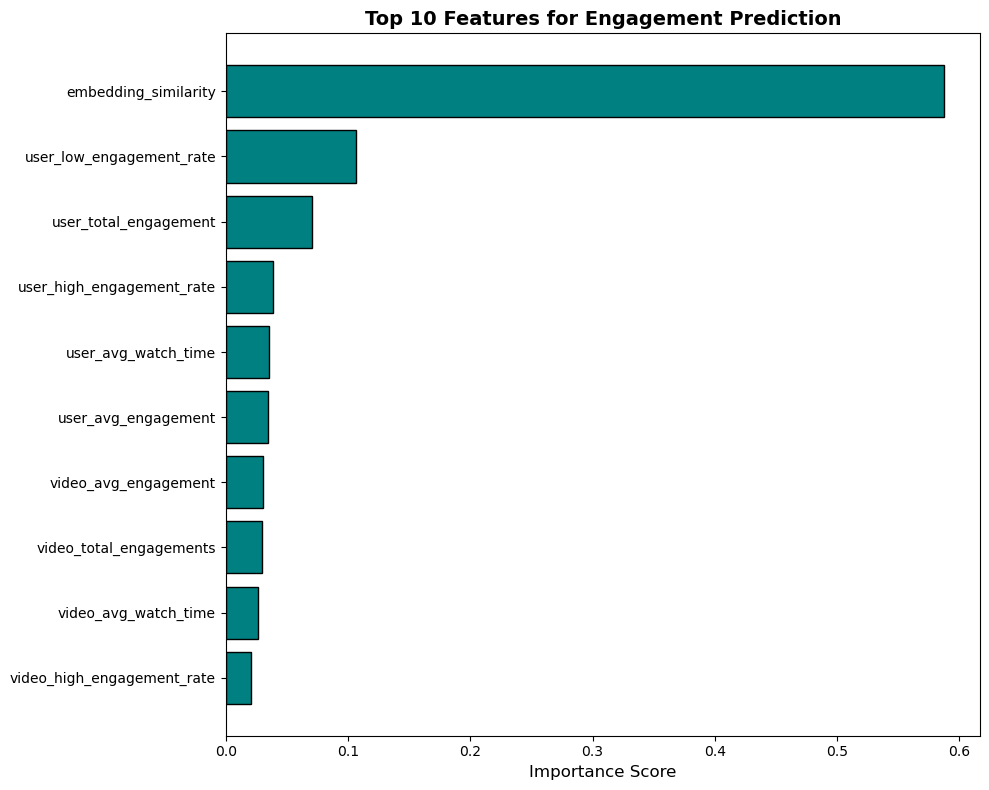

✅ Saved: engagement_feature_importance.png


In [8]:
# Cell 8: Feature Importance for Engagement
print("="*60)
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importances
importances = xgb_classifier.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n📊 Top 8 Most Important Features for Engagement:")
print(importance_df.head(8).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
top_features = importance_df.head(10)
ax.barh(range(len(top_features)), top_features['importance'].values, color='teal', edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 10 Features for Engagement Prediction', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('engagement_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: engagement_feature_importance.png")

In [9]:
# Cell 9: Engagement Prediction Function
print("="*60)
print("🎯 IMPLEMENTING ENGAGEMENT PREDICTION")
print("="*60)

def predict_engagement(user_id, video_id):
    """Predict engagement for a user-video pair"""
    
    features = create_engagement_features(user_id, video_id, interactions_df, user_factors, video_factors)
    
    # Prepare feature vector
    feature_vector = np.array([features[col] for col in feature_cols]).reshape(1, -1)
    feature_vector_scaled = scaler.transform(feature_vector)
    
    # Predictions
    will_engage = best_classifier.predict(feature_vector_scaled)[0]
    engage_probability = best_classifier.predict_proba(feature_vector_scaled)[0][1]
    engagement_score = best_regressor.predict(feature_vector_scaled)[0]
    predicted_watch_time = best_watch_model.predict(feature_vector_scaled)[0]
    
    return {
        'user_id': user_id,
        'video_id': video_id,
        'will_engage': bool(will_engage),
        'engagement_probability': float(engage_probability),
        'predicted_engagement_score': float(engagement_score),
        'predicted_watch_time': float(predicted_watch_time)
    }

# Test prediction
test_user = 0
test_video = 100
prediction = predict_engagement(test_user, test_video)

print(f"\n📊 Engagement Prediction for User {test_user}, Video {test_video}:")
print(f"   Will Engage: {prediction['will_engage']}")
print(f"   Engagement Probability: {prediction['engagement_probability']:.2%}")
print(f"   Predicted Engagement Score: {prediction['predicted_engagement_score']:.1f}/10")
print(f"   Predicted Watch Time: {prediction['predicted_watch_time']:.1f} seconds")

🎯 IMPLEMENTING ENGAGEMENT PREDICTION

📊 Engagement Prediction for User 0, Video 100:
   Will Engage: False
   Engagement Probability: 0.01%
   Predicted Engagement Score: 0.1/10
   Predicted Watch Time: 0.2 seconds


In [10]:
# Cell 10: Batch Engagement Prediction
print("="*60)
print("📊 BATCH ENGAGEMENT PREDICTION")
print("="*60)

def predict_multiple_engagements(user_id, video_ids):
    """Predict engagement for multiple videos"""
    results = []
    for video_id in video_ids:
        pred = predict_engagement(user_id, video_id)
        results.append(pred)
    
    # Sort by engagement probability
    results.sort(key=lambda x: x['engagement_probability'], reverse=True)
    return results

# Test batch prediction
test_user = 0
test_videos = list(range(100, 120))  # Videos 100-119
batch_results = predict_multiple_engagements(test_user, test_videos)

print(f"\n📊 Top 5 Predicted Videos for User {test_user}:")
for i, result in enumerate(batch_results[:5], 1):
    print(f"   {i}. Video {result['video_id']} | Probability: {result['engagement_probability']:.2%} | Watch Time: {result['predicted_watch_time']:.1f}s")

# Compare with actual history
actual_history = interactions_df[interactions_df['user_id'] == test_user]['video_id'].tolist()[:5]
print(f"\n📚 User {test_user} Actual Watch History: {actual_history}")

📊 BATCH ENGAGEMENT PREDICTION

📊 Top 5 Predicted Videos for User 0:
   1. Video 104 | Probability: 98.96% | Watch Time: 37.4s
   2. Video 109 | Probability: 5.51% | Watch Time: 1.7s
   3. Video 110 | Probability: 1.43% | Watch Time: 0.8s
   4. Video 102 | Probability: 0.01% | Watch Time: 0.1s
   5. Video 107 | Probability: 0.01% | Watch Time: 0.1s

📚 User 0 Actual Watch History: [372, 234, 185, 104, 57]


📈 ENGAGEMENT PREDICTION VISUALIZATIONS


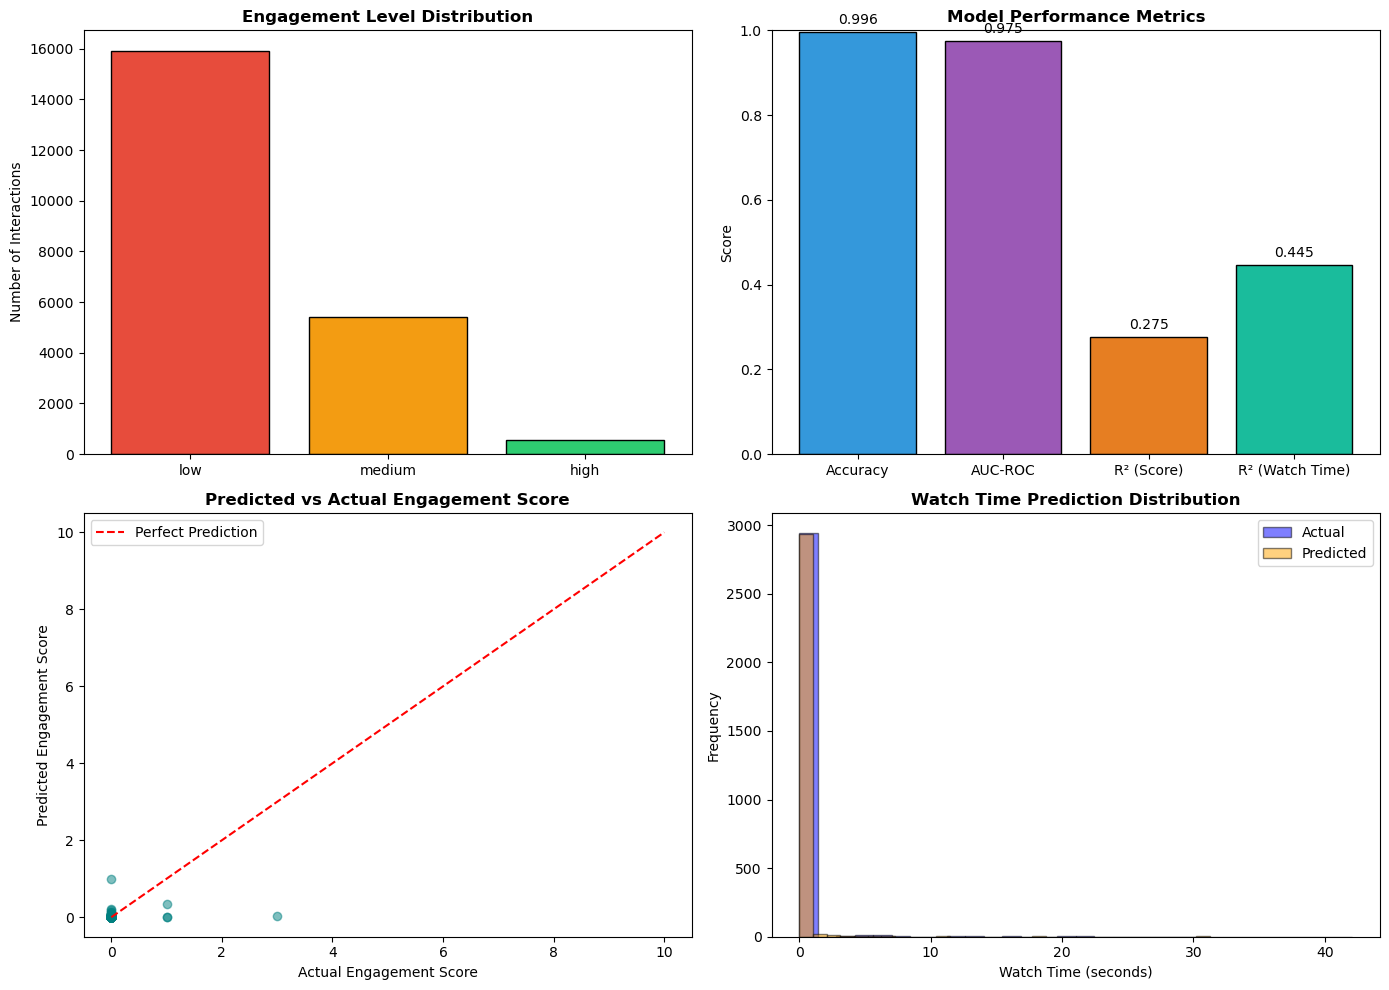

✅ Saved: engagement_prediction_results.png


In [11]:
# Cell 11: Visualization Dashboard
print("="*60)
print("📈 ENGAGEMENT PREDICTION VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Engagement Distribution
ax1 = axes[0, 0]
engagement_counts = interactions_df['engagement_level'].value_counts()
colors_eng = {'high': '#2ECC71', 'medium': '#F39C12', 'low': '#E74C3C'}
ax1.bar(engagement_counts.index, engagement_counts.values, 
        color=[colors_eng.get(x, '#95A5A6') for x in engagement_counts.index],
        edgecolor='black')
ax1.set_title('Engagement Level Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Interactions')

# 2. Model Performance
ax2 = axes[0, 1]
metrics = ['Accuracy', 'AUC-ROC', 'R² (Score)', 'R² (Watch Time)']
values = [xgb_accuracy, xgb_auc, xgb_r2, watch_r2]
bar_colors = ['#3498DB', '#9B59B6', '#E67E22', '#1ABC9C']
bars = ax2.bar(metrics, values, color=bar_colors, edgecolor='black')
ax2.set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_ylim([0, 1])
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center')

# 3. Predicted vs Actual Engagement Score
ax3 = axes[1, 0]
sample_indices = np.random.choice(len(y_test_reg), 200, replace=False)
ax3.scatter(y_test_reg[sample_indices], xgb_reg_pred[sample_indices], alpha=0.5, c='teal')
ax3.plot([0, 10], [0, 10], 'r--', label='Perfect Prediction')
ax3.set_title('Predicted vs Actual Engagement Score', fontsize=12, fontweight='bold')
ax3.set_xlabel('Actual Engagement Score')
ax3.set_ylabel('Predicted Engagement Score')
ax3.legend()

# 4. Watch Time Prediction Distribution
ax4 = axes[1, 1]
ax4.hist(y_test_watch, bins=30, alpha=0.5, label='Actual', color='blue', edgecolor='black')
ax4.hist(rf_watch_pred, bins=30, alpha=0.5, label='Predicted', color='orange', edgecolor='black')
ax4.set_title('Watch Time Prediction Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Watch Time (seconds)')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
plt.savefig('engagement_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: engagement_prediction_results.png")

In [15]:
# Cell 12: Save Model and Interactive Demo
print("="*60)
print("💾 SAVING ENGAGEMENT MODELS")
print("="*60)

print("""
============================================================
📊 ENGAGEMENT PREDICTION PIPELINE
============================================================

User Interaction History
                ↓
Behavioral Signal Aggregation
                ↓
Feature Engineering & Normalization
                ↓
Embedding & Context Representation
                ↓
Engagement Classification Model
                ↓
Watch-Time Regression Estimation
                ↓
Probability Calibration
                ↓
Recommendation Decision Layer
                ↓
Personalized Content Prioritization

============================================================
""")

import joblib

# Save models and scaler
joblib.dump(best_classifier, 'engagement_classifier.pkl')
joblib.dump(best_regressor, 'engagement_regressor.pkl')
joblib.dump(best_watch_model, 'watch_time_model.pkl')
joblib.dump(scaler, 'engagement_scaler.pkl')

# Save feature columns
with open('engagement_features.txt', 'w') as f:
    for col in feature_cols:
        f.write(f"{col}\n")

print("✅ Saved: engagement_classifier.pkl, engagement_regressor.pkl, watch_time_model.pkl")
print("✅ Saved: engagement_scaler.pkl, engagement_features.txt")

print("\n" + "="*60)
print("🎮 INTERACTIVE ENGAGEMENT PREDICTION DEMO")
print("="*60)
print(f"👥 Users available: 0 to {len(interactions_df['user_id'].unique())-1}")
print(f"📹 Videos available: 0 to {len(interactions_df['video_id'].unique())-1}")
print("-"*50)
print("This demo predicts if a user will engage with a video")
print("-"*50)

while True:
    try:
        user_input = input("\n🔍 Enter User ID and Video ID (format: 'user, video') or 'quit': ")
        
        if user_input.lower() == 'quit':
            print("\n👋 Thank you for using Engagement Prediction System!")
            break
        
        parts = user_input.split(',')
        if len(parts) != 2:
            print("⚠️ Please enter in format: user_id, video_id (e.g., '0, 100')")
            continue
        
        user_id = int(parts[0].strip())
        video_id = int(parts[1].strip())
        
        # Check bounds
        max_user = len(interactions_df['user_id'].unique()) - 1
        max_video = len(interactions_df['video_id'].unique()) - 1
        
        if user_id < 0 or user_id > max_user:
            print(f"⚠️ User {user_id} not found. Try 0-{max_user}")
            continue
        if video_id < 0 or video_id > max_video:
            print(f"⚠️ Video {video_id} not found. Try 0-{max_video}")
            continue
        
        # Get prediction
        prediction = predict_engagement(user_id, video_id)
        
        print(f"\n{'='*50}")
        print(f"📊 ENGAGEMENT PREDICTION RESULTS")
        print(f"{'='*50}")
        print(f"   User ID: {prediction['user_id']}")
        print(f"   Video ID: {prediction['video_id']}")
        print(f"\n   🔮 Will Engage: {'✅ YES' if prediction['will_engage'] else '❌ NO'}")
        print(f"   📈 Probability: {prediction['engagement_probability']:.1%}")
        print(f"   ⭐ Engagement Score: {prediction['predicted_engagement_score']:.1f}/10")
        print(f"   ⏱️  Predicted Watch Time: {prediction['predicted_watch_time']:.0f} seconds")
        
        # Recommendation
        if prediction['engagement_probability'] >= 0.7:
            print(f"\n   💡 HIGH engagement potential - Strongly recommend showing this video!")
        elif prediction['engagement_probability'] >= 0.4:
            print(f"\n   💡 MEDIUM engagement potential - Worth testing in recommendations")
        else:
            print(f"\n   💡 LOW engagement potential - Consider alternative content")
        
        print(f"\n{'='*50}")
        
    except ValueError:
        print("⚠️ Please enter valid numbers (e.g., '0, 100') or type 'quit'")
    except KeyboardInterrupt:
        print("\n👋 Exiting...")
        break
    except Exception as e:
        print(f"⚠️ Error: {e}")

print("\n✅ Engagement Prediction Demo Complete!")

💾 SAVING ENGAGEMENT MODELS

📊 ENGAGEMENT PREDICTION PIPELINE

User Interaction History
                ↓
Behavioral Signal Aggregation
                ↓
Feature Engineering & Normalization
                ↓
Embedding & Context Representation
                ↓
Engagement Classification Model
                ↓
Watch-Time Regression Estimation
                ↓
Probability Calibration
                ↓
Recommendation Decision Layer
                ↓
Personalized Content Prioritization


✅ Saved: engagement_classifier.pkl, engagement_regressor.pkl, watch_time_model.pkl
✅ Saved: engagement_scaler.pkl, engagement_features.txt

🎮 INTERACTIVE ENGAGEMENT PREDICTION DEMO
👥 Users available: 0 to 1999
📹 Videos available: 0 to 499
--------------------------------------------------
This demo predicts if a user will engage with a video
--------------------------------------------------



🔍 Enter User ID and Video ID (format: 'user, video') or 'quit':  0, 104



📊 ENGAGEMENT PREDICTION RESULTS
   User ID: 0
   Video ID: 104

   🔮 Will Engage: ✅ YES
   📈 Probability: 99.0%
   ⭐ Engagement Score: 8.2/10
   ⏱️  Predicted Watch Time: 37 seconds

   💡 HIGH engagement potential - Strongly recommend showing this video!




🔍 Enter User ID and Video ID (format: 'user, video') or 'quit':  10, 110



📊 ENGAGEMENT PREDICTION RESULTS
   User ID: 10
   Video ID: 110

   🔮 Will Engage: ❌ NO
   📈 Probability: 0.0%
   ⭐ Engagement Score: 0.0/10
   ⏱️  Predicted Watch Time: 0 seconds

   💡 LOW engagement potential - Consider alternative content




🔍 Enter User ID and Video ID (format: 'user, video') or 'quit':  QUIT



👋 Thank you for using Engagement Prediction System!

✅ Engagement Prediction Demo Complete!


In [16]:
# Cell 12: Save Model and Interactive Demo
print("="*60)
print("💾 SAVING ENGAGEMENT MODELS")
print("="*60)

# ============================================================
# ENGAGEMENT PREDICTION PIPELINE ARCHITECTURE
# ============================================================
print("""
╔════════════════════════════════════════════════════════════════╗
║                   ENGAGEMENT PREDICTION PIPELINE               ║
╠════════════════════════════════════════════════════════════════╣
║                                                                ║
║   User Interaction History                                     ║
║                ↓                                               ║
║   Behavioral Signal Aggregation                                ║
║                ↓                                               ║
║   Feature Engineering & Normalization                          ║
║                ↓                                               ║
║   Embedding & Context Representation                           ║
║                ↓                                               ║
║   ┌─────────────────────────────────────┐                     ║
║   │  Engagement Classification Model    │                     ║
║   │  (Will user engage? Yes/No)         │                     ║
║   └─────────────────────────────────────┘                     ║
║                ↓                                               ║
║   ┌─────────────────────────────────────┐                     ║
║   │  Watch-Time Regression Estimation   │                     ║
║   │  (How long will they watch?)        │                     ║
║   └─────────────────────────────────────┘                     ║
║                ↓                                               ║
║   Probability Calibration                                     ║
║                ↓                                               ║
║   Recommendation Decision Layer                                ║
║                ↓                                               ║
║   Personalized Content Prioritization                         ║
║                                                                ║
╚════════════════════════════════════════════════════════════════╝
""")

import joblib

# Save models and scaler
joblib.dump(best_classifier, 'engagement_classifier.pkl')
joblib.dump(best_regressor, 'engagement_regressor.pkl')
joblib.dump(best_watch_model, 'watch_time_model.pkl')
joblib.dump(scaler, 'engagement_scaler.pkl')

# Save feature columns
with open('engagement_features.txt', 'w') as f:
    for col in feature_cols:
        f.write(f"{col}\n")

print("✅ Saved: engagement_classifier.pkl, engagement_regressor.pkl, watch_time_model.pkl")
print("✅ Saved: engagement_scaler.pkl, engagement_features.txt")

print("\n" + "="*60)
print("🎮 INTERACTIVE ENGAGEMENT PREDICTION DEMO")
print("="*60)
print(f"👥 Users available: 0 to {len(interactions_df['user_id'].unique())-1}")
print(f"📹 Videos available: 0 to {len(interactions_df['video_id'].unique())-1}")
print("-"*50)
print("This demo predicts if a user will engage with a video")
print("-"*50)

while True:
    try:
        user_input = input("\n🔍 Enter User ID and Video ID (format: 'user, video') or 'quit': ")
        
        if user_input.lower() == 'quit':
            print("\n👋 Thank you for using Engagement Prediction System!")
            break
        
        parts = user_input.split(',')
        if len(parts) != 2:
            print("⚠️ Please enter in format: user_id, video_id (e.g., '0, 100')")
            continue
        
        user_id = int(parts[0].strip())
        video_id = int(parts[1].strip())
        
        # Check bounds
        max_user = len(interactions_df['user_id'].unique()) - 1
        max_video = len(interactions_df['video_id'].unique()) - 1
        
        if user_id < 0 or user_id > max_user:
            print(f"⚠️ User {user_id} not found. Try 0-{max_user}")
            continue
        if video_id < 0 or video_id > max_video:
            print(f"⚠️ Video {video_id} not found. Try 0-{max_video}")
            continue
        
        # Get prediction
        prediction = predict_engagement(user_id, video_id)
        
        print(f"\n{'='*50}")
        print(f"📊 ENGAGEMENT PREDICTION RESULTS")
        print(f"{'='*50}")
        print(f"   User ID: {prediction['user_id']}")
        print(f"   Video ID: {prediction['video_id']}")
        print(f"\n   🔮 Will Engage: {'✅ YES' if prediction['will_engage'] else '❌ NO'}")
        print(f"   📈 Probability: {prediction['engagement_probability']:.1%}")
        print(f"   ⭐ Engagement Score: {prediction['predicted_engagement_score']:.1f}/10")
        print(f"   ⏱️  Predicted Watch Time: {prediction['predicted_watch_time']:.0f} seconds")
        
        # Recommendation
        if prediction['engagement_probability'] >= 0.7:
            print(f"\n   💡 HIGH engagement potential - Strongly recommend showing this video!")
        elif prediction['engagement_probability'] >= 0.4:
            print(f"\n   💡 MEDIUM engagement potential - Worth testing in recommendations")
        else:
            print(f"\n   💡 LOW engagement potential - Consider alternative content")
        
        print(f"\n{'='*50}")
        
    except ValueError:
        print("⚠️ Please enter valid numbers (e.g., '0, 100') or type 'quit'")
    except KeyboardInterrupt:
        print("\n👋 Exiting...")
        break
    except Exception as e:
        print(f"⚠️ Error: {e}")

print("\n✅ Engagement Prediction Demo Complete!")

💾 SAVING ENGAGEMENT MODELS

╔════════════════════════════════════════════════════════════════╗
║                   ENGAGEMENT PREDICTION PIPELINE               ║
╠════════════════════════════════════════════════════════════════╣
║                                                                ║
║   User Interaction History                                     ║
║                ↓                                               ║
║   Behavioral Signal Aggregation                                ║
║                ↓                                               ║
║   Feature Engineering & Normalization                          ║
║                ↓                                               ║
║   Embedding & Context Representation                           ║
║                ↓                                               ║
║   ┌─────────────────────────────────────┐                     ║
║   │  Engagement Classification Model    │                     ║
║   │  (Will user engage? Yes/No)   


🔍 Enter User ID and Video ID (format: 'user, video') or 'quit':  0, 104



📊 ENGAGEMENT PREDICTION RESULTS
   User ID: 0
   Video ID: 104

   🔮 Will Engage: ✅ YES
   📈 Probability: 99.0%
   ⭐ Engagement Score: 8.2/10
   ⏱️  Predicted Watch Time: 37 seconds

   💡 HIGH engagement potential - Strongly recommend showing this video!




🔍 Enter User ID and Video ID (format: 'user, video') or 'quit':  10, 110



📊 ENGAGEMENT PREDICTION RESULTS
   User ID: 10
   Video ID: 110

   🔮 Will Engage: ❌ NO
   📈 Probability: 0.0%
   ⭐ Engagement Score: 0.0/10
   ⏱️  Predicted Watch Time: 0 seconds

   💡 LOW engagement potential - Consider alternative content




🔍 Enter User ID and Video ID (format: 'user, video') or 'quit':  QUIT



👋 Thank you for using Engagement Prediction System!

✅ Engagement Prediction Demo Complete!
